Notebook for analyzing results.

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [24]:
df = pd.read_json('results.json', lines=True)
df['no_fail'] = df['no_fail'].fillna(1)
cols = {'t': 'Time',
        'no_fail': 'No Fail',
        'weight_acc': 'Weighted Acc.',
        'edr': 'EDR',
        'ttd': 'TTD',
        'env': 'Environment',
        'method': 'Method'
}
df = df.rename(columns=cols)
df = df.replace({
    'cd': 'CD',
    'cd_ae': 'CD-AE',
    'dist': 'Dist',
    'ae_rec': 'AE-REC',
    'cd_rp': 'CD-RP'
})
df = df.replace({
    'inv_pend': 'Inv. Pend.',
    'hopper': 'Hopper',
    'half_cheetah': 'Half Cheetah',
    'ant': 'Ant',
    'humanoid': 'Humanoid'
})

#drop_rows = [0, 1, 8, 9, 10, 12, 13, 14, 16, 17, 18, 23]
df

,Method,Environment,enc,No Fail,hid,lat,proj,deg,tpr,tnr,bal_acc,Weighted Acc.,TTD,EDR,Time
0,CD,Half Cheetah,None,1.0,NaN,NaN,NaN,1,0.970085,0.808094,0.889090,0.846,15.525991,0.779736,0.060031
1,CD,Half Cheetah,None,1.0,NaN,NaN,NaN,2,0.940171,0.831593,0.885882,0.857,13.906364,0.763636,0.634395
2,CD,Half Cheetah,None,1.0,NaN,NaN,NaN,3,0.944444,0.821149,0.882797,0.850,15.023982,0.773756,5.443483
3,CD-AE,Half Cheetah,version_0,1.0,64.0,5.0,NaN,1,0.482906,0.821149,0.652027,0.742,10.370796,0.725664,0.009829
4,CD-AE,Half Cheetah,version_0,1.0,64.0,5.0,NaN,2,0.542735,0.869452,0.706093,0.793,10.399213,0.692913,0.021861
5,CD-AE,Half Cheetah,version_0,1.0,64.0,5.0,NaN,3,0.589744,0.869452,0.729598,0.804,9.886957,0.688406,0.052297
6,CD-AE,Half Cheetah,version_0,1.0,64.0,5.0,NaN,4,0.611111,0.866841,0.738976,0.807,10.816783,0.706294,0.114240
7,CD-AE,Half Cheetah,version_0,1.0,64.0,5.0,NaN,5,0.632479,0.856397,0.744438,0.804,12.977703,0.736486,0.255816
8,CD-AE,Half Cheetah,version_1,1.0,64.0,10.0,NaN,1,0.606838,0.864230,0.735534,0.804,13.811268,0.760563,0.017393
9,CD-AE,Half Cheetah,version_1,1.0,64.0,10.0,NaN,2,0.670940,0.851175,0.761058,0.809,13.675159,0.732484,0.081472


In [48]:
df['lat'] = df['lat'].replace(np.NaN, 23)
df = df.rename(columns={"lat": "n"})

Text(0.5, 1.0, 'WACC and EDR for different degree and embedding sizes')

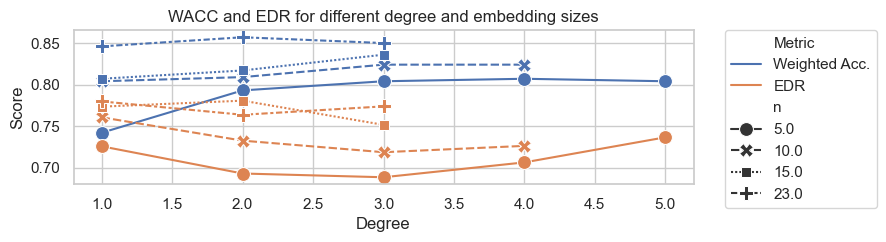

In [57]:
fig, ax = plt.subplots(figsize=(8, 2))

df_long = df.melt(
    id_vars=["deg", "n"], 
    value_vars=["Weighted Acc.", "EDR"],
    var_name="Metric", 
    value_name="Score"
)

sns.lineplot(
    data=df_long,
    x="deg", y="Score",
    hue="Metric",      # <-- colors
    style="n",       # <-- markers
    markers=True,
    markersize=10
)

plt.legend(
    bbox_to_anchor=(1.05, 1),   # x, y position relative to the axes
    loc="upper left",           # which corner of the legend box to anchor
    borderaxespad=0
)

plt.xlabel('Degree')
plt.ylabel('Score')
plt.title('WACC and EDR for different degree and embedding sizes')

In [3]:
df = df.drop(drop_rows)
df = df[df['No Fail'] == 1.0]
df

,Method,Environment,enc,No Fail,hid,lat,proj,deg,tpr,tnr,bal_acc,Weighted Acc.,TTD,EDR,Time
2,CD,Inv. Pend.,None,1.0,NaN,NaN,NaN,6,1.000000,0.813820,0.906910,0.903,2.731315,0.645094,0.540513
3,CD-AE,Inv. Pend.,version_0,1.0,64.0,5.0,NaN,6,1.000000,0.785029,0.892514,0.888,2.756367,0.649269,0.536286
5,Dist,Inv. Pend.,None,1.0,NaN,NaN,NaN,3,1.000000,0.585413,0.792706,0.784,1.892067,0.584551,0.098443
6,AE-REC,Inv. Pend.,version_0,1.0,64.0,5.0,NaN,3,0.993737,0.673704,0.833721,0.827,0.465126,0.537815,0.007300
7,CD-RP,Inv. Pend.,None,1.0,NaN,NaN,5.0,6,0.997912,0.794626,0.896269,0.892,1.132845,0.527197,0.551517
11,CD,Hopper,None,1.0,NaN,NaN,NaN,4,1.000000,0.876543,0.938272,0.970,22.042404,1.000000,5.428963
15,CD-AE,Hopper,version_0,1.0,64.0,5.0,NaN,6,1.000000,0.703704,0.851852,0.928,21.492867,1.000000,0.560010
20,Dist,Hopper,None,1.0,NaN,NaN,NaN,3,1.000000,0.292181,0.646091,0.828,31.405680,1.000000,0.050196
21,AE-REC,Hopper,version_0,1.0,64.0,5.0,NaN,3,1.000000,0.765432,0.882716,0.943,20.253765,0.988111,0.009610
22,CD-RP,Hopper,None,1.0,NaN,NaN,5.0,6,0.998679,0.806584,0.902632,0.952,19.144577,0.989418,0.550017


In [4]:
metrics = ['Weighted Acc.', 'EDR', 'TTD', 'Time']
df = df.set_index(['Environment', 'Method'])[metrics]
df

Weighted Acc.       EDR        TTD      Time
Environment  Method                                              
Inv. Pend.   CD              0.903  0.645094   2.731315  0.540513
             CD-AE           0.888  0.649269   2.756367  0.536286
             Dist            0.784  0.584551   1.892067  0.098443
             AE-REC          0.827  0.537815   0.465126  0.007300
             CD-RP           0.892  0.527197   1.132845  0.551517
Hopper       CD              0.970  1.000000  22.042404  5.428963
             CD-AE           0.928  1.000000  21.492867  0.560010
             Dist            0.828  1.000000  31.405680  0.050196
             AE-REC          0.943  0.988111  20.253765  0.009610
             CD-RP           0.952  0.989418  19.144577  0.550017
Half Cheetah CD-AE           0.824  0.706215  10.820904  1.390290
             Dist            0.764  0.798942  13.972487  0.163611
             AE-REC          0.826  0.683616  11.007345  0.010470
             CD-RP           0.860  0.694581  10.722167  1.352331
Ant          CD-AE           0.728  0.750000  17.438636  1.074317
             Dist            0.622  0.645161  15.301075  0.205563
             AE-REC          0.927  0.302632  -1.593421  0.035923
             CD-RP           0.740  0.730337  16.912360  1.218149
Humanoid     CD-AE           0.829  0.655779  11.941709  1.099550
             Dist            0.657  0.884712  22.311529  0.204912
             AE-REC          0.795  0.645729  15.192965  0.071554
             CD-RP           0.804  0.754386  14.141103  1.078150

In [5]:
def highlight_group(group):
    out = group.copy()

    # Convert to string first so we can safely insert LaTeX commands
    for col in ["Weighted Acc.", "EDR", "TTD", "Time"]:
        out[col] = group[col].map(lambda v: f"{v:.3f}")

    # Bold maxima
    for col in ["Weighted Acc.", "EDR", "TTD"]:
        idxmax = group[col].idxmax()
        out.loc[idxmax, col] = f"\\textbf{{{group.loc[idxmax, col]:.3f}}}"

    # Bold minimum for Time
    idxmin = group["Time"].idxmin()
    out.loc[idxmin, "Time"] = f"\\textbf{{{group.loc[idxmin, 'Time']:.3f}}}"

    return out

df_bold = (
    df.groupby(level=0, group_keys=False, sort=False)
      .apply(highlight_group)
)

latex_table = df_bold.to_latex(
    escape=False,
    multirow=True,
    multicolumn_format="c"
)


In [6]:
print(latex_table)

\begin{tabular}{llllll}
\toprule
 &  & Weighted Acc. & EDR & TTD & Time \\
Environment & Method &  &  &  &  \\
\midrule
\multirow[t]{5}{*}{Inv. Pend.} & CD & \textbf{0.903} & 0.645 & 2.731 & 0.541 \\
 & CD-AE & 0.888 & \textbf{0.649} & \textbf{2.756} & 0.536 \\
 & Dist & 0.784 & 0.585 & 1.892 & 0.098 \\
 & AE-REC & 0.827 & 0.538 & 0.465 & \textbf{0.007} \\
 & CD-RP & 0.892 & 0.527 & 1.133 & 0.552 \\
\cline{1-6}
\multirow[t]{5}{*}{Hopper} & CD & \textbf{0.970} & \textbf{1.000} & 22.042 & 5.429 \\
 & CD-AE & 0.928 & 1.000 & 21.493 & 0.560 \\
 & Dist & 0.828 & 1.000 & \textbf{31.406} & 0.050 \\
 & AE-REC & 0.943 & 0.988 & 20.254 & \textbf{0.010} \\
 & CD-RP & 0.952 & 0.989 & 19.145 & 0.550 \\
\cline{1-6}
\multirow[t]{4}{*}{Half Cheetah} & CD-AE & 0.824 & 0.706 & 10.821 & 1.390 \\
 & Dist & 0.764 & \textbf{0.799} & \textbf{13.972} & 0.164 \\
 & AE-REC & 0.826 & 0.684 & 11.007 & \textbf{0.010} \\
 & CD-RP & \textbf{0.860} & 0.695 & 10.722 & 1.352 \\
\cline{1-6}
\multirow[t]{4}{*}{Ant} & CD-

In [217]:
latex_table = df.to_latex(
    multicolumn=True,
    multicolumn_format="c",
    float_format="%.3f",
    escape=False
)

print(latex_table)


\begin{tabular}{llrrrr}
\toprule
 &  & Weighted Acc. & EDR & TTD & Time \\
Environment & Method &  &  &  &  \\
\midrule
\multirow[t]{5}{*}{Inv. Pend.} & CD & 0.903 & 0.645 & 2.731 & 2.497 \\
 & CD-AE & 0.904 & 0.628 & 2.459 & 2.467 \\
 & Dist & 0.784 & 0.585 & 1.892 & 0.100 \\
 & AE-REC & 0.870 & 0.487 & 0.897 & 0.007 \\
 & CD-RP & 0.892 & 0.527 & 1.133 & 2.115 \\
\cline{1-6}
\multirow[t]{5}{*}{Hopper} & CD & 0.970 & 1.000 & 22.042 & 11.579 \\
 & CD-AE & 0.944 & 0.999 & 21.382 & 1.290 \\
 & Dist & 0.828 & 1.000 & 31.406 & 0.048 \\
 & AE-REC & 0.941 & 0.985 & 13.200 & 0.009 \\
 & CD-RP & 0.952 & 0.989 & 19.145 & 1.271 \\
\cline{1-6}
\multirow[t]{4}{*}{Half Cheetah} & CD-AE & 0.825 & 0.717 & 9.887 & 6.488 \\
 & Dist & 0.764 & 0.799 & 13.972 & 0.164 \\
 & AE-REC & 0.837 & 0.674 & 9.135 & 0.012 \\
 & CD-RP & 0.860 & 0.695 & 10.722 & 4.918 \\
\cline{1-6}
\multirow[t]{4}{*}{Ant} & CD-AE & 0.742 & 0.701 & 14.955 & 2.117 \\
 & Dist & 0.622 & 0.645 & 15.301 & 0.201 \\
 & AE-REC & 0.757 & 0.693 

In [182]:
print(latex_table)

\begin{tabular}{llllll}
\toprule
 &  & 0 & 1 & 2 & 3 \\
Environment & Method &  &  &  &  \\
\midrule
\multirow[t]{5}{*}{Inv. Pend.} & CD & 0.90 & 0.65 & \textbf{2.73} & 2.50 \\
 & CD-AE & 0.90 & 0.63 & 2.46 & \textbf{2.47} \\
 & Dist & 0.78 & 0.58 & \textbf{1.89} & 0.10 \\
 & AE-REC & 0.87 & 0.49 & \textbf{0.90} & 0.01 \\
 & CD-RP & 0.89 & 0.53 & 1.13 & \textbf{2.12} \\
\cline{1-6}
\multirow[t]{5}{*}{Hopper} & CD & 0.97 & 1.00 & \textbf{22.04} & 11.58 \\
 & CD-AE & 0.94 & 1.00 & \textbf{21.38} & 1.29 \\
 & Dist & 0.83 & 1.00 & \textbf{31.41} & 0.05 \\
 & AE-REC & 0.94 & 0.99 & \textbf{13.20} & 0.01 \\
 & CD-RP & 0.95 & 0.99 & \textbf{19.14} & 1.27 \\
\cline{1-6}
\multirow[t]{4}{*}{Half Cheetah} & CD-AE & 0.83 & 0.72 & \textbf{9.89} & 6.49 \\
 & Dist & 0.76 & 0.80 & \textbf{13.97} & 0.16 \\
 & AE-REC & 0.84 & 0.67 & \textbf{9.14} & 0.01 \\
 & CD-RP & 0.86 & 0.69 & \textbf{10.72} & 4.92 \\
\cline{1-6}
\multirow[t]{4}{*}{Ant} & CD-AE & 0.74 & 0.70 & \textbf{14.96} & 2.12 \\
 & Dist & 0.62

In [81]:
df[(df['env'] == 'hopper') & (df['method'] == 'cd')].plot('deg', 'ttd', marker='s')

KeyError: 'env'